In [21]:
from __future__ import annotations

from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from experiments import (
    get_agent_dirs,
    get_player_names,
    load_selfplay_results,
    load_tournament_results,
    setup_publication_style,
)

In [22]:
# === Configuration ===
# Choose game: "pd" (IPD), "chicken", or "stag"
GAME: Literal["pd", "chicken", "stag"] = "pd"

# Proposal plots use two noise levels (as requested)
NOISE_LEVELS: list[float] = [0.0, 0.05]

# Data roots (relative to this notebook: experiments/other/)
TOURNAMENT_ROOT = Path("../../results/main") / GAME
SELFPLAY_ROOT = Path("../../results/sp") / GAME

# Output directory for proposal figures
OUTPUT_DIR = (Path("../../results/main") / GAME / "plots" / "proposal")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Bar order / modes
MODES: list[Literal["static", "adaptive", "crossplay", "selfplay"]] = [
    "static",
    "adaptive",
    "crossplay",
    "selfplay",
]
MODE_LABEL = {
    "static": "Static",
    "adaptive": "Adaptive",
    "crossplay": "Crossplay",
    "selfplay": "Selfplay",
}

# Agent index groups
GROUPS: dict[str, list[int]] = {
    "AIF": [7, 8, 9],
    "MARL": [0, 1, 5, 6],
    "Heuristic": [2, 3, 4],
}

# Ablations (7 and 9 compared against base 8)
ABLATIONS: list[tuple[str, int, int]] = [
    ("Epistemic", 7, 8),
    ("Noise+Epistemic", 9, 8),
]

# Convenience paths for tournament pools
POOL_DIR_BY_MODE = {
    "static": TOURNAMENT_ROOT / "static",
    "adaptive": TOURNAMENT_ROOT / "learning",
}

# Selfplay directory
SP_DIR = SELFPLAY_ROOT

print(f"GAME={GAME}")
print(f"TOURNAMENT_ROOT={TOURNAMENT_ROOT}")
print(f"SELFPLAY_ROOT={SELFPLAY_ROOT}")
print(f"OUTPUT_DIR={OUTPUT_DIR}")


GAME=pd
TOURNAMENT_ROOT=../../results/main/pd
SELFPLAY_ROOT=../../results/sp/pd
OUTPUT_DIR=../../results/main/pd/plots/proposal


In [23]:
# === Shared plot style ===
setup_publication_style(use_latex=False, font_size=10)

# Bar colors (bars now represent categories / ablations)
BESTOF_BAR_COLORS = {
    "AIF": "#4C78A8",       # blue
    "MARL": "#F58518",      # orange
    "Heuristic": "#54A24B", # green
}

ABLATION_BAR_COLORS = {
    "Epistemic": "#4C78A8",
    "Noise+Epistemic": "#B279A2",
}

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [24]:
# === Helpers (loading, CI, best-of selection, plotting) ===

def _t_ci95(arr: np.ndarray, *, clip01: bool = False) -> tuple[float, float, float, int]:
    """Return (mean, ci_lower, ci_upper, n) using a 95% t-interval."""
    arr = np.asarray(arr, dtype=float)
    arr = arr[~np.isnan(arr)]
    n = int(arr.size)
    if n == 0:
        return (np.nan, np.nan, np.nan, 0)

    mean = float(np.mean(arr))

    if n == 1:
        lo = hi = mean
    else:
        std = float(np.std(arr, ddof=1))
        if not np.isfinite(std) or std <= 0:
            lo = hi = mean
        else:
            ci = stats.t.interval(0.95, n - 1, loc=mean, scale=std / np.sqrt(n))
            lo, hi = float(ci[0]), float(ci[1])
            if not np.isfinite(lo) or not np.isfinite(hi):
                lo = hi = mean

    if clip01:
        lo = max(0.0, lo)
        hi = min(1.0, hi)
    return (mean, lo, hi, n)


def _find_agent_dir(pool_dir: Path, agent_idx: int) -> str:
    matches = sorted([p.name for p in pool_dir.glob(f"{agent_idx}_*") if p.is_dir()])
    if not matches:
        raise FileNotFoundError(f"No agent dir for idx={agent_idx} in {pool_dir}")
    return matches[0]


def _tournament_rep_values(
    pool_dir: Path,
    agent_idx: int,
    noise: float,
    metric: Literal["score", "cc_rate"],
) -> dict[int, float]:
    agent_dir = _find_agent_dir(pool_dir, agent_idx)
    df = load_tournament_results(pool_dir, agent_dir, noise)
    if df.empty:
        return {}

    agent_df = df[df["Player index"] == 0]
    out: dict[int, float] = {}

    for rep in sorted(agent_df["repetition"].unique()):
        rep_df = agent_df[agent_df["repetition"] == rep]
        if rep_df.empty:
            continue

        if metric == "score":
            out[int(rep)] = float(rep_df["Score"].mean())
        else:
            turns = float(rep_df["Turns"].sum())
            if turns <= 0:
                continue
            cc = float(rep_df["CC count"].sum())
            out[int(rep)] = cc / turns

    return out


def _tournament_agg(
    pool_dir: Path,
    noise: float,
    metric: Literal["score", "cc_rate"],
) -> pd.DataFrame:
    rows: list[dict] = []
    for dir_name, _display in get_agent_dirs(pool_dir):
        try:
            agent_idx = int(dir_name.split("_")[0])
        except Exception:
            continue

        rep_map = _tournament_rep_values(pool_dir, agent_idx, noise, metric)
        arr = np.array(list(rep_map.values()), dtype=float)
        mean, lo, hi, n = _t_ci95(arr, clip01=(metric == "cc_rate"))
        rows.append(
            {
                "agent_idx": agent_idx,
                "mean": mean,
                "ci_lower": lo,
                "ci_upper": hi,
                "n": n,
            }
        )

    df = pd.DataFrame(rows)
    if df.empty:
        return df
    return df.sort_values("agent_idx").reset_index(drop=True)


def _selfplay_rep_values(
    sp_dir: Path,
    agent_idx: int,
    noise: float,
    metric: Literal["score", "cc_rate"],
    *,
    diagonal: bool,
) -> dict[int, float]:
    df = load_selfplay_results(sp_dir, noise)
    if df.empty:
        return {}

    player_names = get_player_names(sp_dir)
    if agent_idx < 0 or agent_idx >= len(player_names):
        raise IndexError(f"agent_idx={agent_idx} out of range for selfplay players={len(player_names)}")

    player = player_names[agent_idx]

    # Filter to this player's perspective
    pdf = df[df["Player name"] == player]
    if pdf.empty:
        return {}

    out: dict[int, float] = {}
    for rep in sorted(pdf["repetition"].unique()):
        rep_df = pdf[pdf["repetition"] == rep]
        if rep_df.empty:
            continue

        if diagonal:
            rep_df = rep_df[rep_df["Opponent name"] == player]
        else:
            rep_df = rep_df[rep_df["Opponent name"] != player]

        if rep_df.empty:
            continue

        if metric == "score":
            out[int(rep)] = float(rep_df["Score"].mean())
        else:
            turns = float(rep_df["Turns"].sum())
            if turns <= 0:
                continue
            cc = float(rep_df["CC count"].sum())
            out[int(rep)] = cc / turns

    return out


def _selfplay_agg(
    sp_dir: Path,
    noise: float,
    metric: Literal["score", "cc_rate"],
    *,
    diagonal: bool,
) -> pd.DataFrame:
    player_names = get_player_names(sp_dir)
    rows: list[dict] = []
    for agent_idx in range(len(player_names)):
        rep_map = _selfplay_rep_values(sp_dir, agent_idx, noise, metric, diagonal=diagonal)
        arr = np.array(list(rep_map.values()), dtype=float)
        mean, lo, hi, n = _t_ci95(arr, clip01=(metric == "cc_rate"))
        rows.append(
            {
                "agent_idx": agent_idx,
                "mean": mean,
                "ci_lower": lo,
                "ci_upper": hi,
                "n": n,
            }
        )

    df = pd.DataFrame(rows)
    return df.sort_values("agent_idx").reset_index(drop=True)


def _best_in_group(agg: pd.DataFrame, agent_indices: list[int]) -> dict:
    sub = agg[agg["agent_idx"].isin(agent_indices)].dropna(subset=["mean"])
    if sub.empty:
        return {"agent_idx": None, "mean": np.nan, "ci_lower": np.nan, "ci_upper": np.nan, "n": 0}
    best_row = sub.sort_values("mean", ascending=False).iloc[0]
    return best_row.to_dict()


def _paired_delta_ci(
    rep_a: dict[int, float],
    rep_b: dict[int, float],
    *,
    clip01: bool = False,
) -> tuple[float, float, float, int]:
    common = sorted(set(rep_a.keys()) & set(rep_b.keys()))
    if not common:
        return (np.nan, np.nan, np.nan, 0)
    deltas = np.array([rep_a[r] - rep_b[r] for r in common], dtype=float)
    return _t_ci95(deltas, clip01=clip01)


def _plot_grouped_bars(
    *,
    group_labels: list[str],
    bar_labels: list[str],
    values: np.ndarray,
    ci_lowers: np.ndarray,
    ci_uppers: np.ndarray,
    bar_colors: dict[str, str] | None,
    ylabel: str,
    title: str,
    save_stem: Path,
    ylim: tuple[float, float] | None = None,
):
    """Grouped bars: shape(values) == (n_groups, n_bars).

    Bars with missing values (NaN/inf) are skipped.
    """
    n_groups = len(group_labels)
    n_bars = len(bar_labels)

    x = np.arange(n_groups, dtype=float)
    width = min(0.8 / max(1, n_bars), 0.25)
    offsets = (np.arange(n_bars) - (n_bars - 1) / 2.0) * width

    fig, ax = plt.subplots(figsize=(10, 4.2))

    bar_labeled: set[str] = set()

    for j, bar_label in enumerate(bar_labels):
        for i in range(n_groups):
            y = float(values[i, j])
            lo = float(ci_lowers[i, j])
            hi = float(ci_uppers[i, j])

            if not np.isfinite(y):
                continue

            if np.isfinite(lo) and np.isfinite(hi):
                yerr_lower = max(0.0, y - lo)
                yerr_upper = max(0.0, hi - y)
                yerr = np.array([[yerr_lower], [yerr_upper]])
            else:
                yerr = None

            label = bar_label if bar_label not in bar_labeled else None
            if label is not None:
                bar_labeled.add(bar_label)

            color = (bar_colors or {}).get(bar_label, None)

            ax.bar(
                x[i] + offsets[j],
                y,
                width=width,
                label=label,
                color=color,
                yerr=yerr,
                capsize=2,
                linewidth=0.6,
                edgecolor="black",
                alpha=0.95,
                error_kw={"elinewidth": 0.8, "capthick": 0.8},
            )

    ax.set_xticks(x)
    ax.set_xticklabels(group_labels)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, axis="y", linestyle="--", alpha=0.25)

    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(
            ncol=min(4, len(handles)),
            loc="upper center",
            bbox_to_anchor=(0.5, 1.18),
            frameon=False,
        )

    if ylim is not None:
        ax.set_ylim(*ylim)

    fig.tight_layout()

    for ext in ["pdf", "png"]:
        fig.savefig(Path(str(save_stem) + f".{ext}"))

    plt.show()


def plot_bestof(
    *,
    noise: float,
    metric: Literal["score", "cc_rate"],
):
    if metric == "score":
        ylabel = "Mean score"
        metric_label = "Score"
        ylim = None
    else:
        ylabel = "Cooperation rate (CC)"
        metric_label = "CC rate"
        ylim = (0.0, 1.0)

    mode_aggs: dict[str, pd.DataFrame] = {}

    # Tournament modes
    for mode in ["static", "adaptive"]:
        pool_dir = POOL_DIR_BY_MODE[mode]
        if pool_dir.exists():
            mode_aggs[mode] = _tournament_agg(pool_dir, noise, metric)
        else:
            mode_aggs[mode] = pd.DataFrame()

    # Selfplay-derived modes
    if SP_DIR.exists():
        mode_aggs["crossplay"] = _selfplay_agg(SP_DIR, noise, metric, diagonal=False)
        mode_aggs["selfplay"] = _selfplay_agg(SP_DIR, noise, metric, diagonal=True)
    else:
        mode_aggs["crossplay"] = pd.DataFrame()
        mode_aggs["selfplay"] = pd.DataFrame()

    group_labels = [MODE_LABEL[m] for m in MODES]
    bar_labels = list(GROUPS.keys())  # AIF/MARL/Heuristic

    values = np.full((len(MODES), len(bar_labels)), np.nan)
    lo = np.full_like(values, np.nan, dtype=float)
    hi = np.full_like(values, np.nan, dtype=float)

    for i_mode, mode in enumerate(MODES):
        agg = mode_aggs.get(mode, pd.DataFrame())
        if agg.empty:
            continue

        for j_bar, group_name in enumerate(bar_labels):
            best = _best_in_group(agg, GROUPS[group_name])
            values[i_mode, j_bar] = best["mean"]
            lo[i_mode, j_bar] = best["ci_lower"]
            hi[i_mode, j_bar] = best["ci_upper"]

    title = f"{GAME.upper()} – Best-of {metric_label} – noise={noise:.2f}"
    save_stem = OUTPUT_DIR / f"bestof_{metric}_{noise:.2f}".replace(".", "p")

    _plot_grouped_bars(
        group_labels=group_labels,
        bar_labels=bar_labels,
        values=values,
        ci_lowers=lo,
        ci_uppers=hi,
        bar_colors=BESTOF_BAR_COLORS,
        ylabel=ylabel,
        title=title,
        save_stem=save_stem,
        ylim=ylim,
    )


def plot_ablation_deltas(
    *,
    noise: float,
    metric: Literal["score", "cc_rate"],
):
    if metric == "score":
        ylabel = "Δ mean score (variant − base)"
        metric_label = "Score"
        clip01 = False
        ylim = None
    else:
        ylabel = "Δ cooperation rate (CC) (variant − base)"
        metric_label = "CC rate"
        clip01 = False  # deltas can be outside [0,1]
        ylim = None

    group_labels = [MODE_LABEL[m] for m in MODES]
    bar_labels = [name for (name, _a, _b) in ABLATIONS]

    values = np.full((len(MODES), len(ABLATIONS)), np.nan)
    lo = np.full_like(values, np.nan, dtype=float)
    hi = np.full_like(values, np.nan, dtype=float)

    for i_mode, mode in enumerate(MODES):
        if mode in ["static", "adaptive"]:
            pool_dir = POOL_DIR_BY_MODE[mode]
            if not pool_dir.exists():
                continue
            for j_bar, (_label, a_idx, b_idx) in enumerate(ABLATIONS):
                rep_a = _tournament_rep_values(pool_dir, a_idx, noise, metric)
                rep_b = _tournament_rep_values(pool_dir, b_idx, noise, metric)
                mean, ci_lo, ci_hi, n = _paired_delta_ci(rep_a, rep_b, clip01=clip01)
                values[i_mode, j_bar] = mean
                lo[i_mode, j_bar] = ci_lo
                hi[i_mode, j_bar] = ci_hi
        else:
            if not SP_DIR.exists():
                continue
            diagonal = mode == "selfplay"
            for j_bar, (_label, a_idx, b_idx) in enumerate(ABLATIONS):
                rep_a = _selfplay_rep_values(SP_DIR, a_idx, noise, metric, diagonal=diagonal)
                rep_b = _selfplay_rep_values(SP_DIR, b_idx, noise, metric, diagonal=diagonal)
                mean, ci_lo, ci_hi, n = _paired_delta_ci(rep_a, rep_b, clip01=clip01)
                values[i_mode, j_bar] = mean
                lo[i_mode, j_bar] = ci_lo
                hi[i_mode, j_bar] = ci_hi

    title = f"{GAME.upper()} – Ablation Δ{metric_label} – noise={noise:.2f} (vs base 8)"
    save_stem = OUTPUT_DIR / f"ablation_delta_{metric}_{noise:.2f}".replace(".", "p")

    _plot_grouped_bars(
        group_labels=group_labels,
        bar_labels=bar_labels,
        values=values,
        ci_lowers=lo,
        ci_uppers=hi,
        bar_colors=ABLATION_BAR_COLORS,
        ylabel=ylabel,
        title=title,
        save_stem=save_stem,
        ylim=ylim,
    )


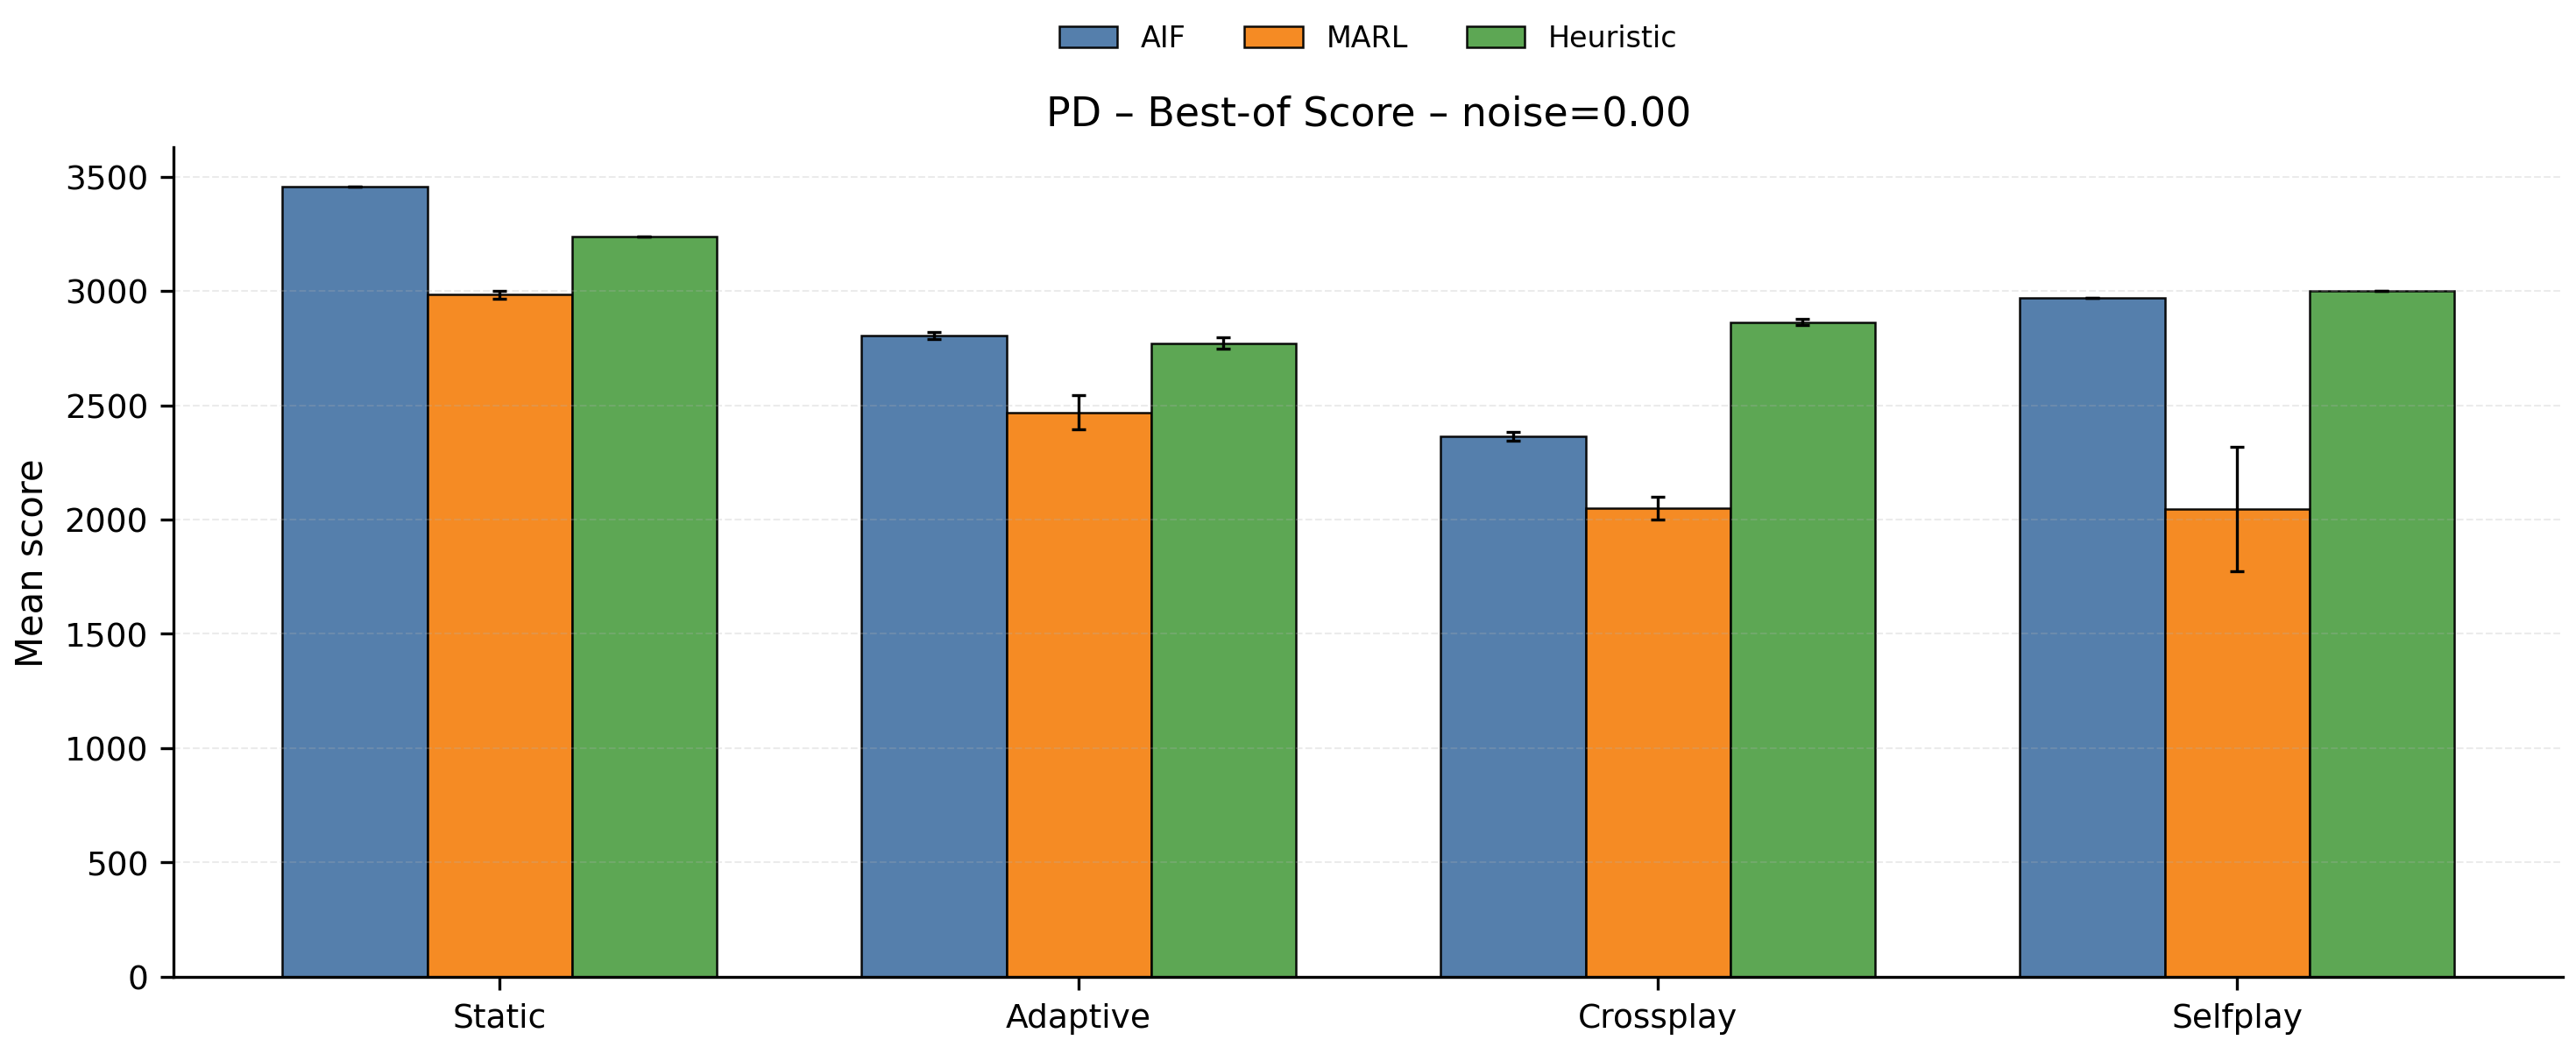

In [25]:
# Plot 1: Best AIF vs Best MARL vs Best Heuristic — Score @ noise 0.00
plot_bestof(noise=NOISE_LEVELS[0], metric="score")

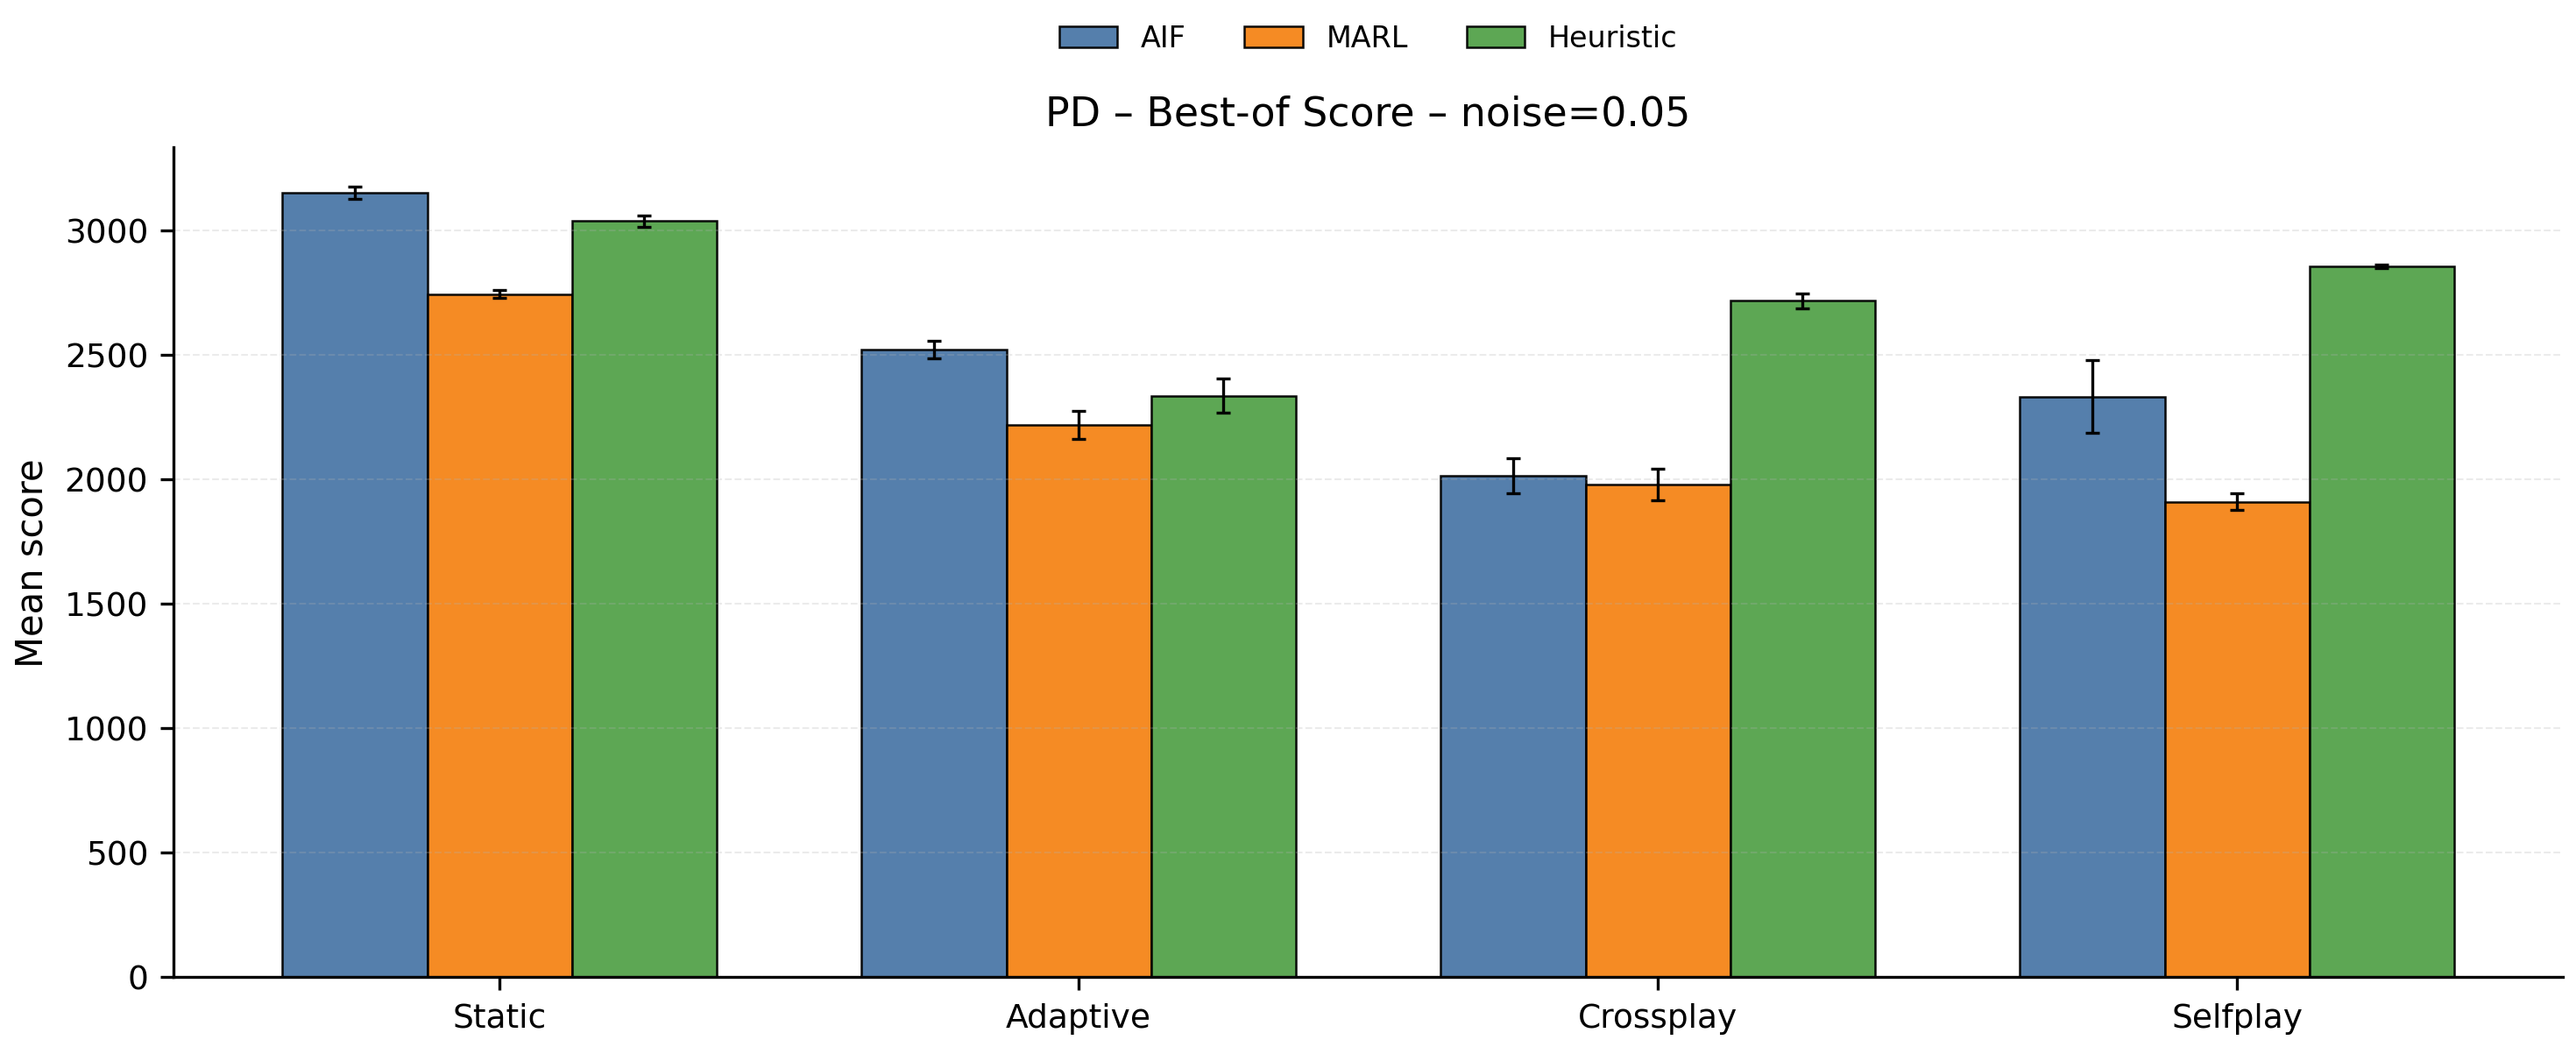

In [26]:
# Plot 2: Best AIF vs Best MARL vs Best Heuristic — Score @ noise 0.05
plot_bestof(noise=NOISE_LEVELS[1], metric="score")

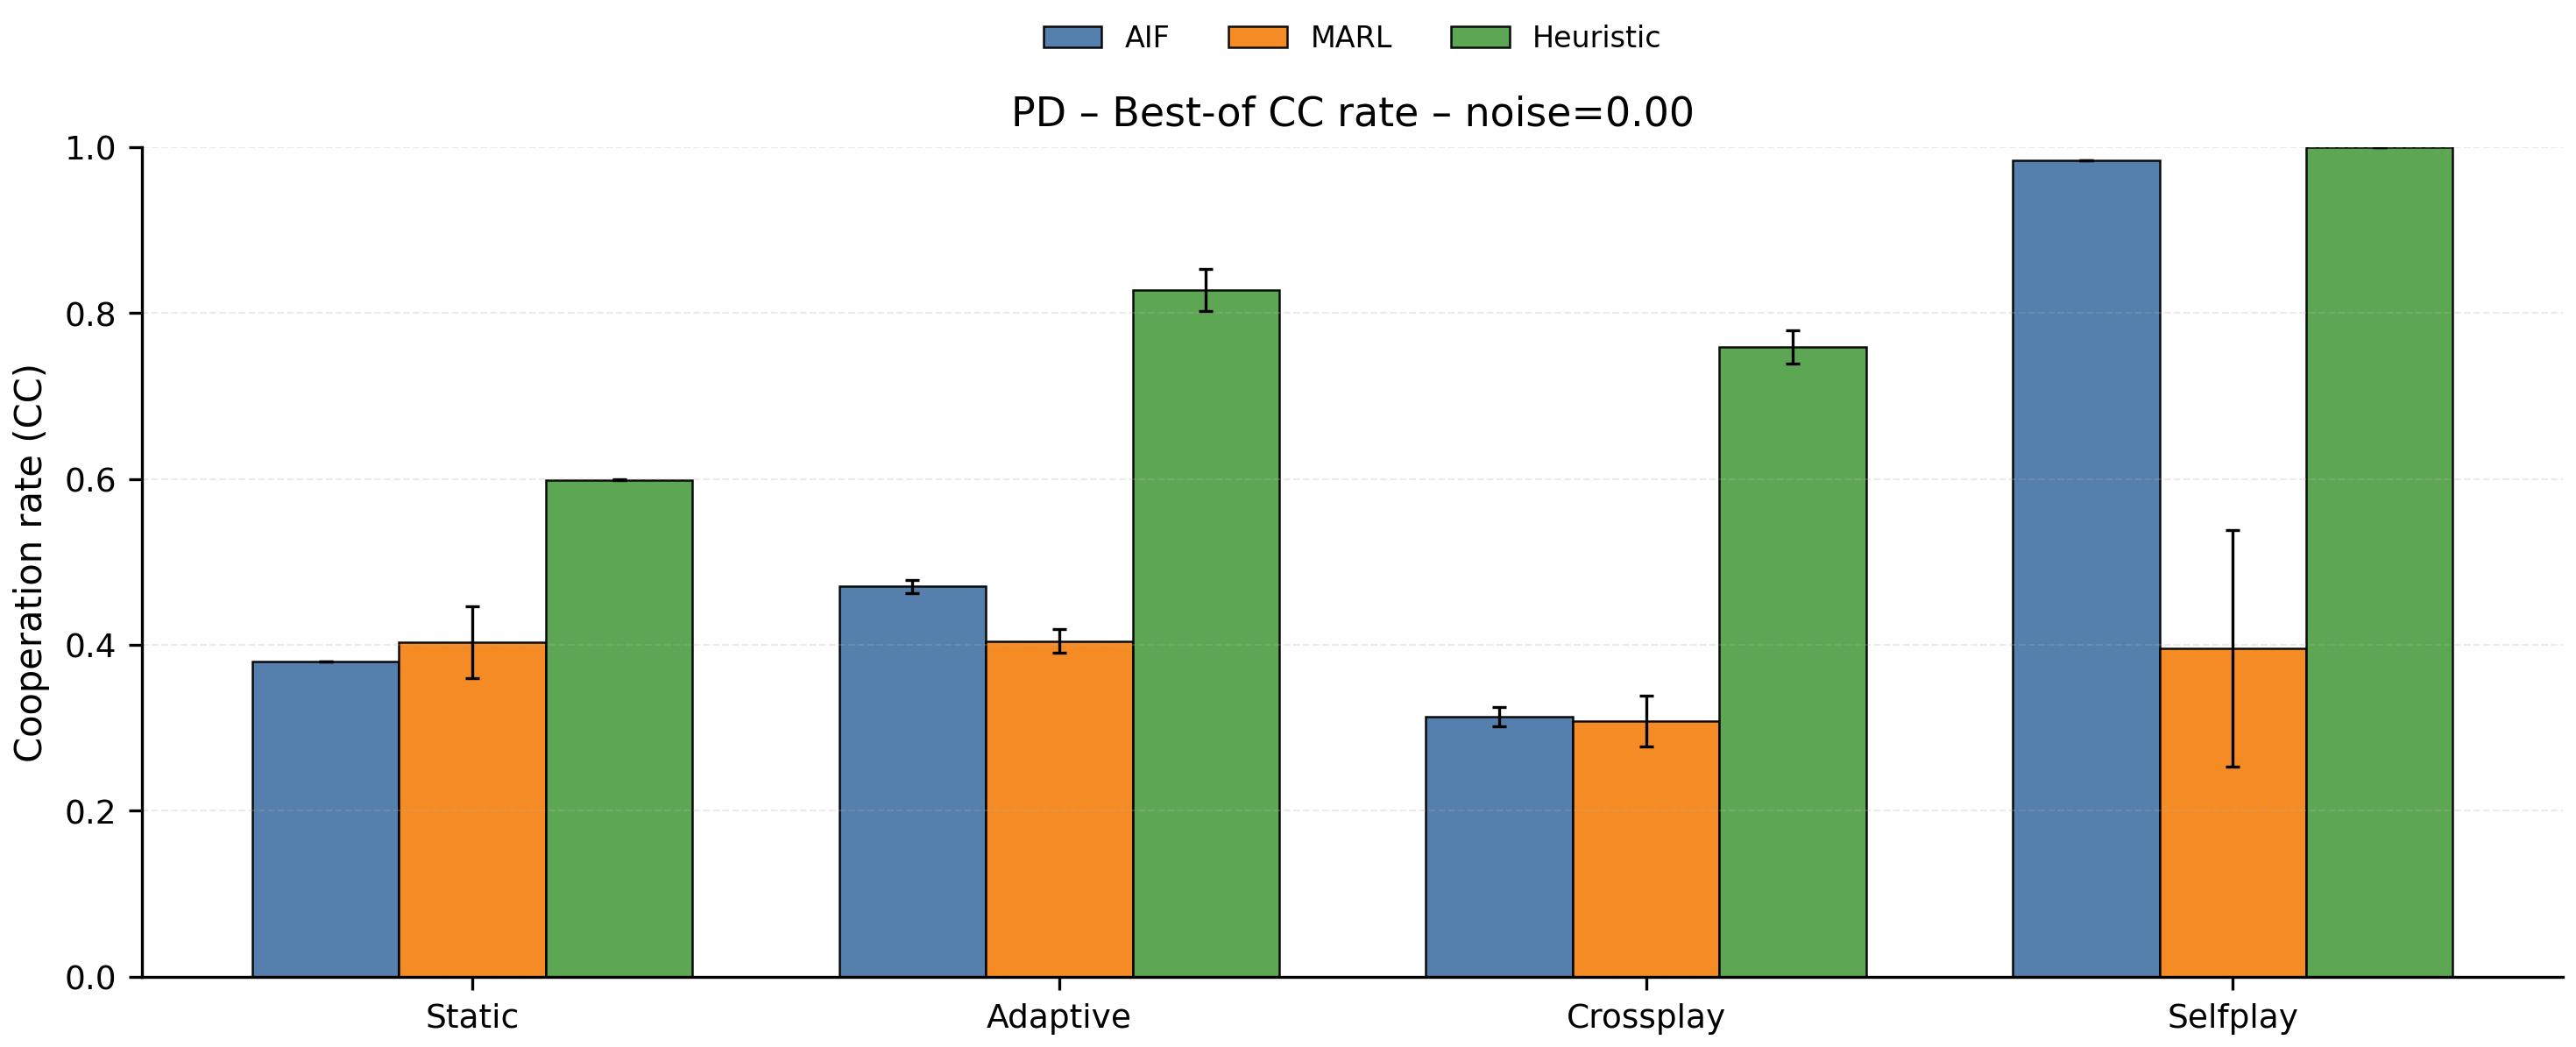

In [27]:
# Plot 3: Best AIF vs Best MARL vs Best Heuristic — CC rate @ noise 0.00
plot_bestof(noise=NOISE_LEVELS[0], metric="cc_rate")

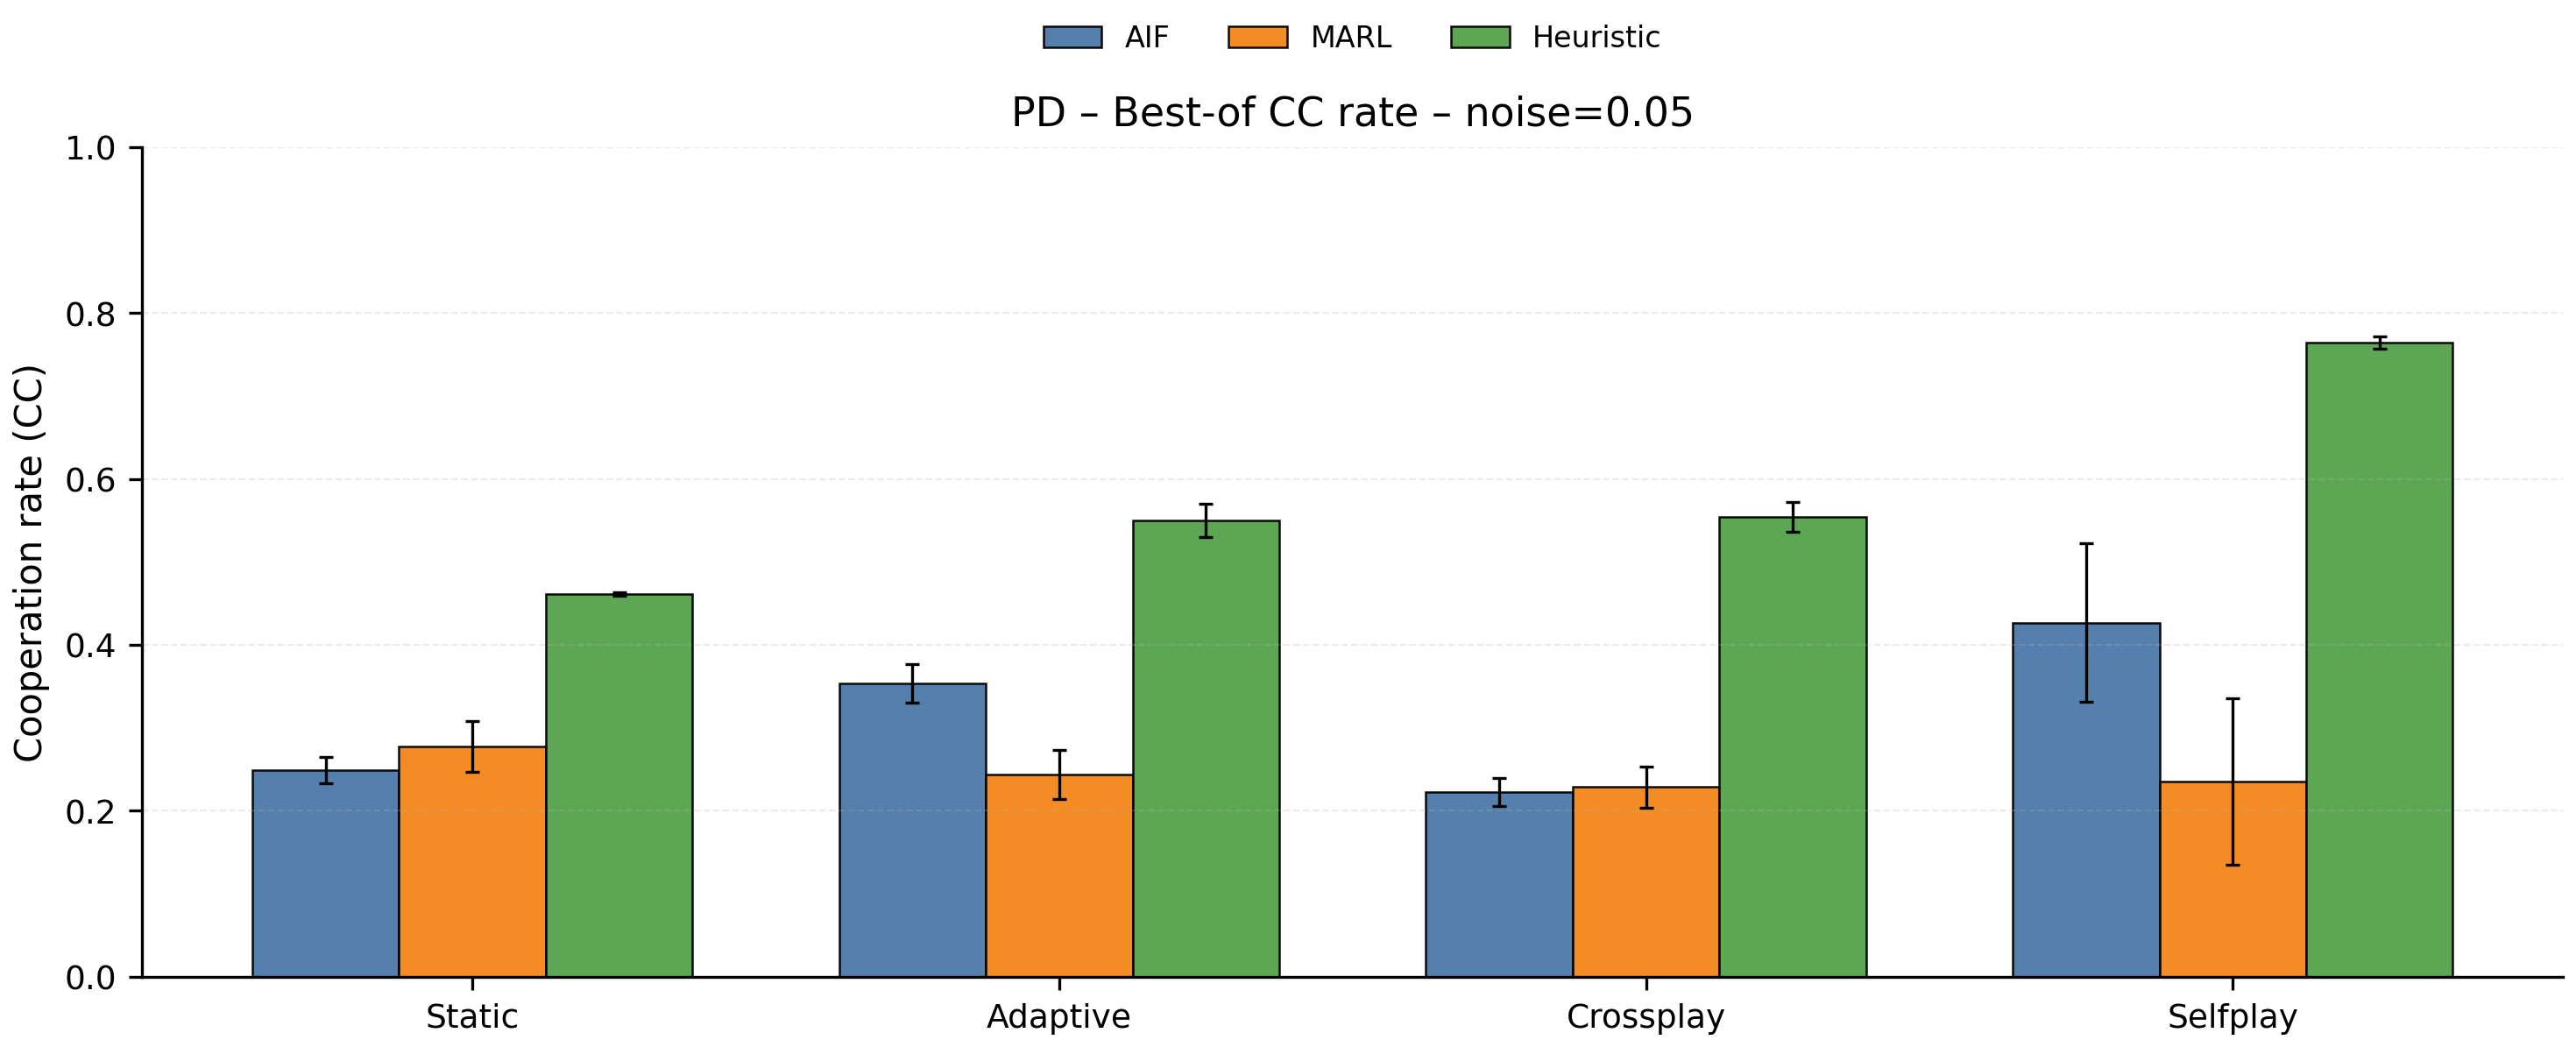

In [28]:
# Plot 4: Best AIF vs Best MARL vs Best Heuristic — CC rate @ noise 0.05
plot_bestof(noise=NOISE_LEVELS[1], metric="cc_rate")

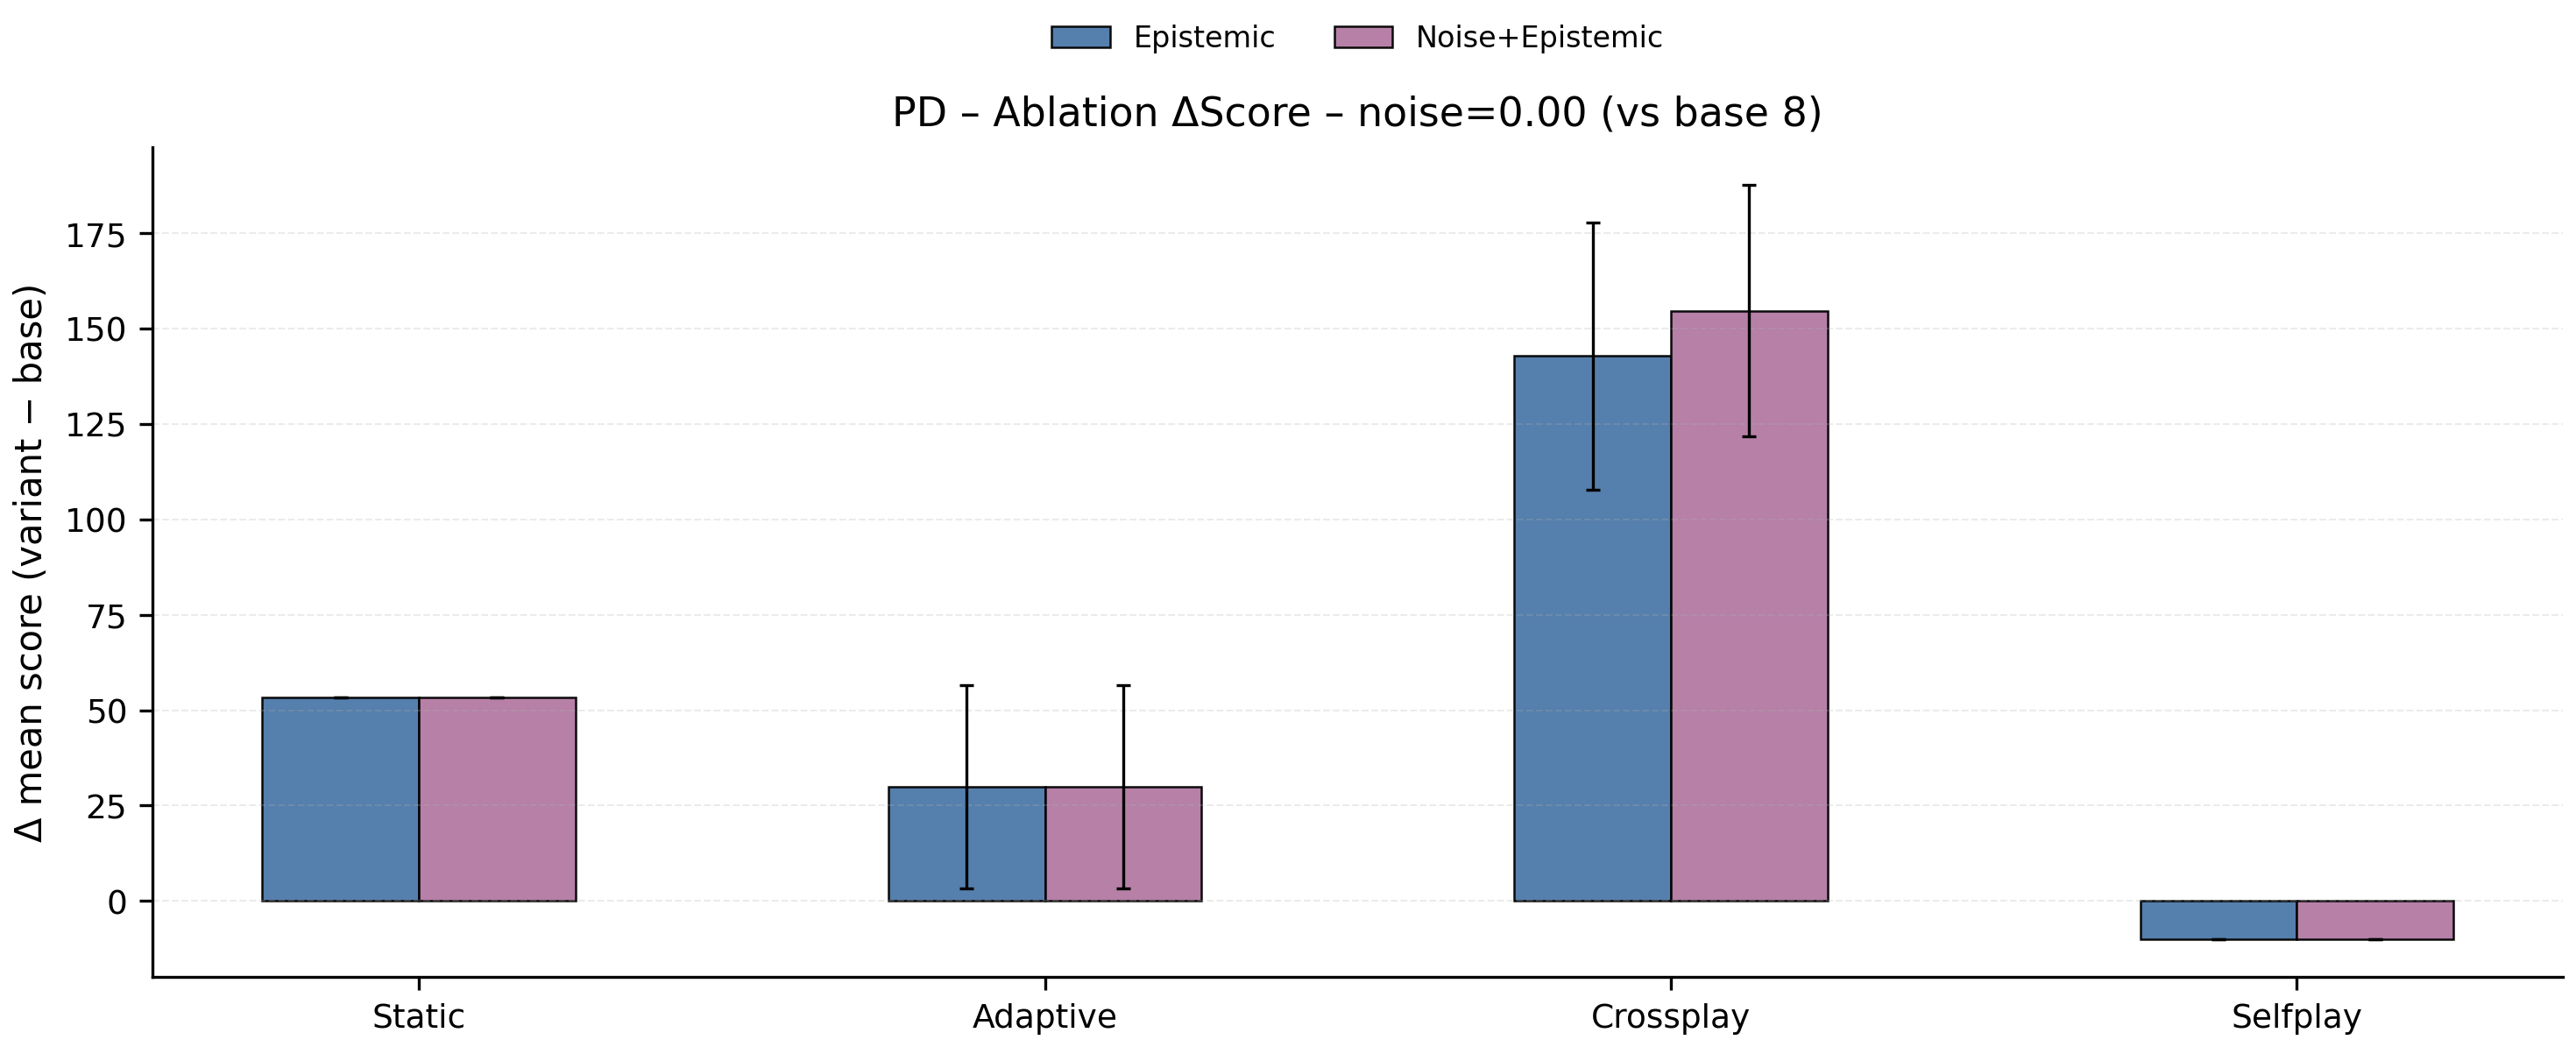

In [29]:
# Plot 5: Ablation deltas vs base (8) — ΔScore @ noise 0.00
plot_ablation_deltas(noise=NOISE_LEVELS[0], metric="score")

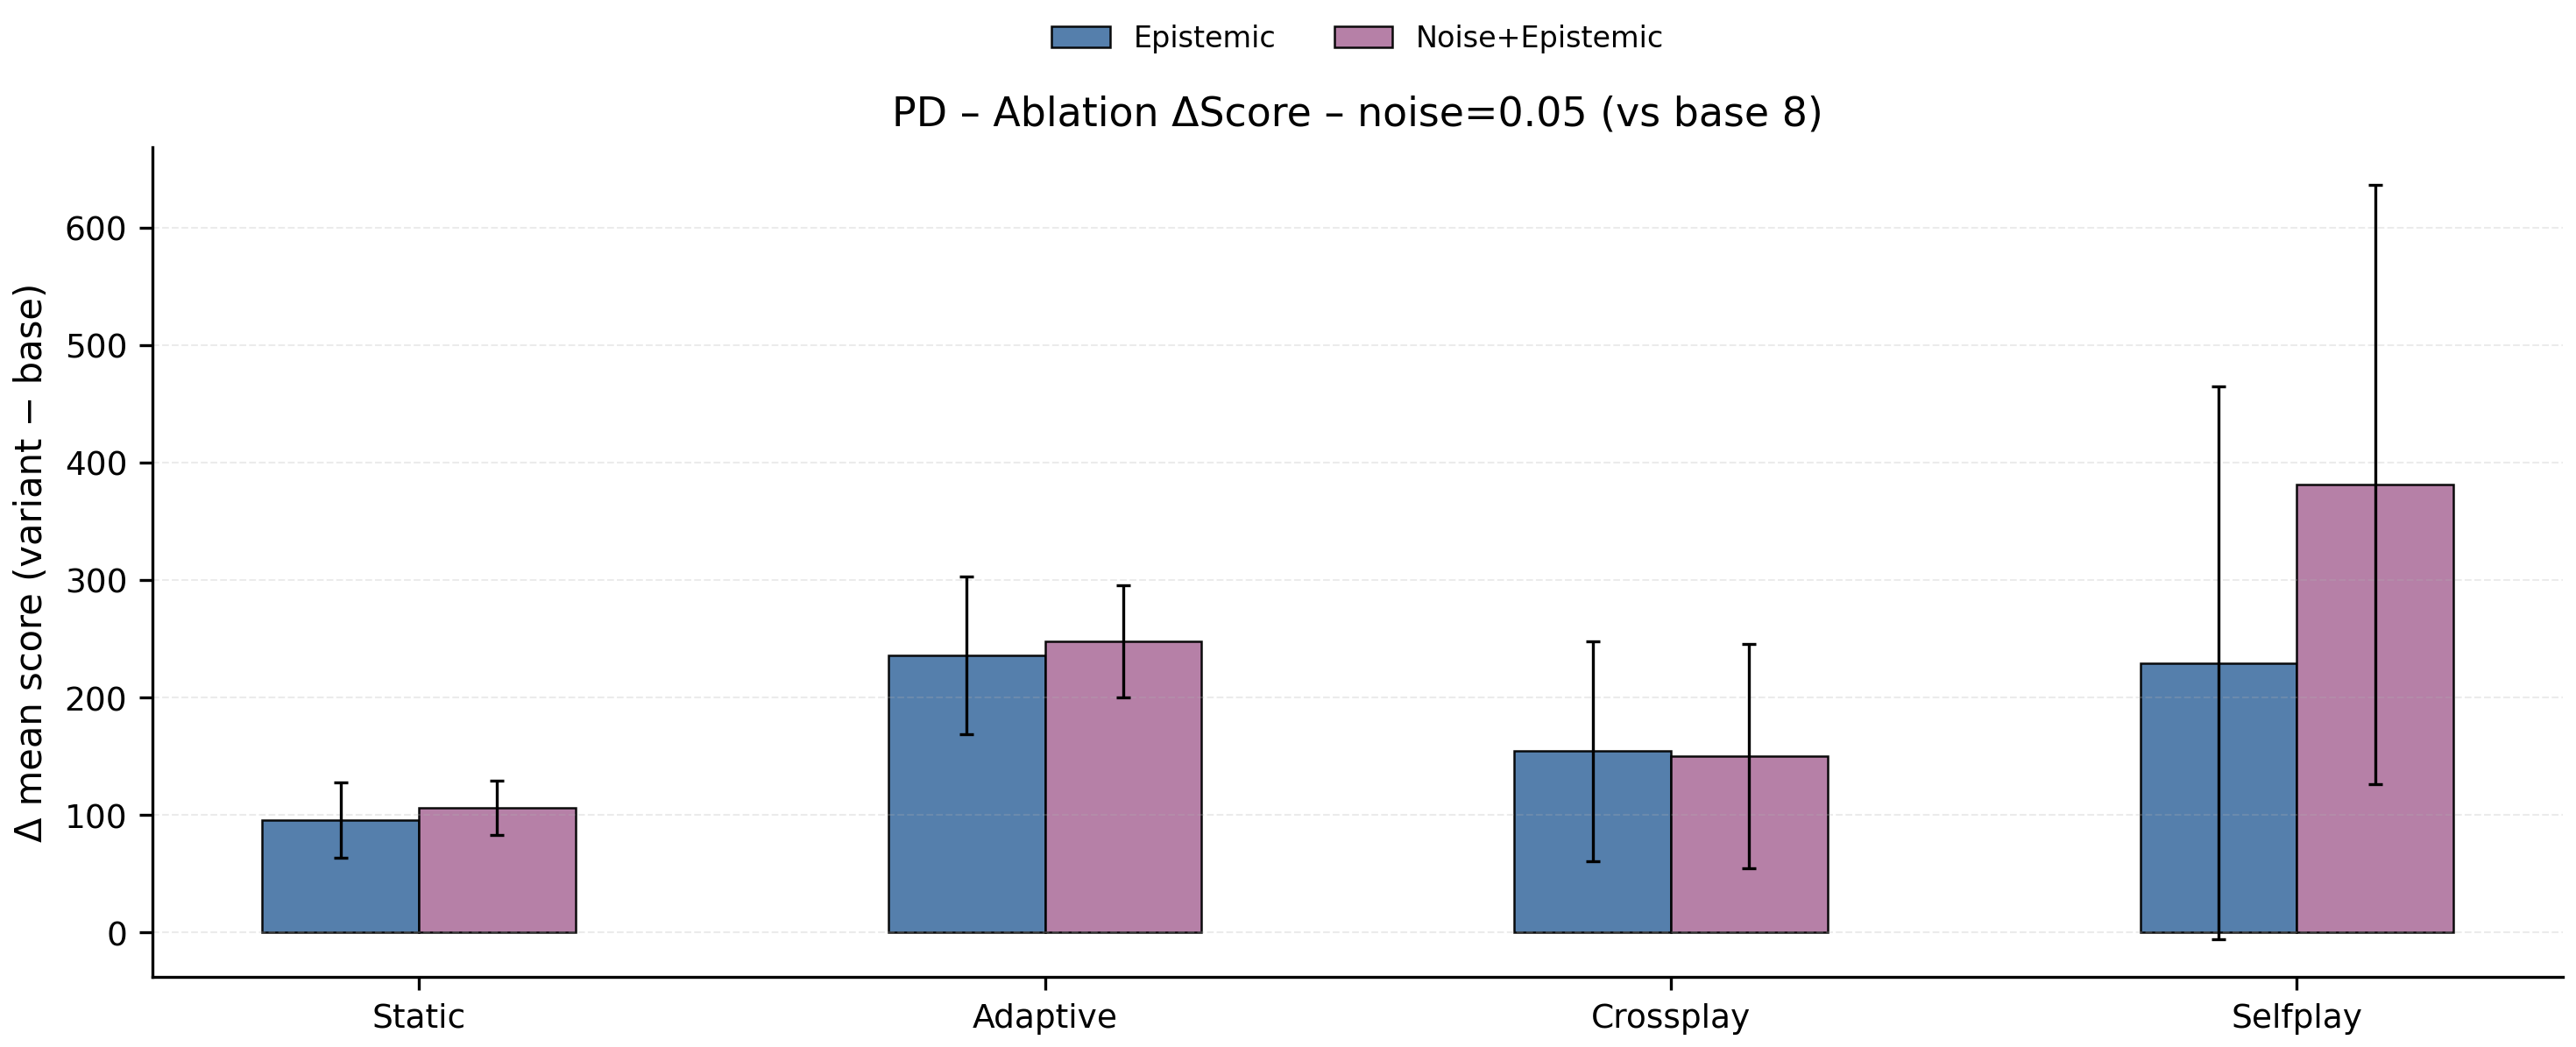

In [30]:
# Plot 6: Ablation deltas vs base (8) — ΔScore @ noise 0.05
plot_ablation_deltas(noise=NOISE_LEVELS[1], metric="score")

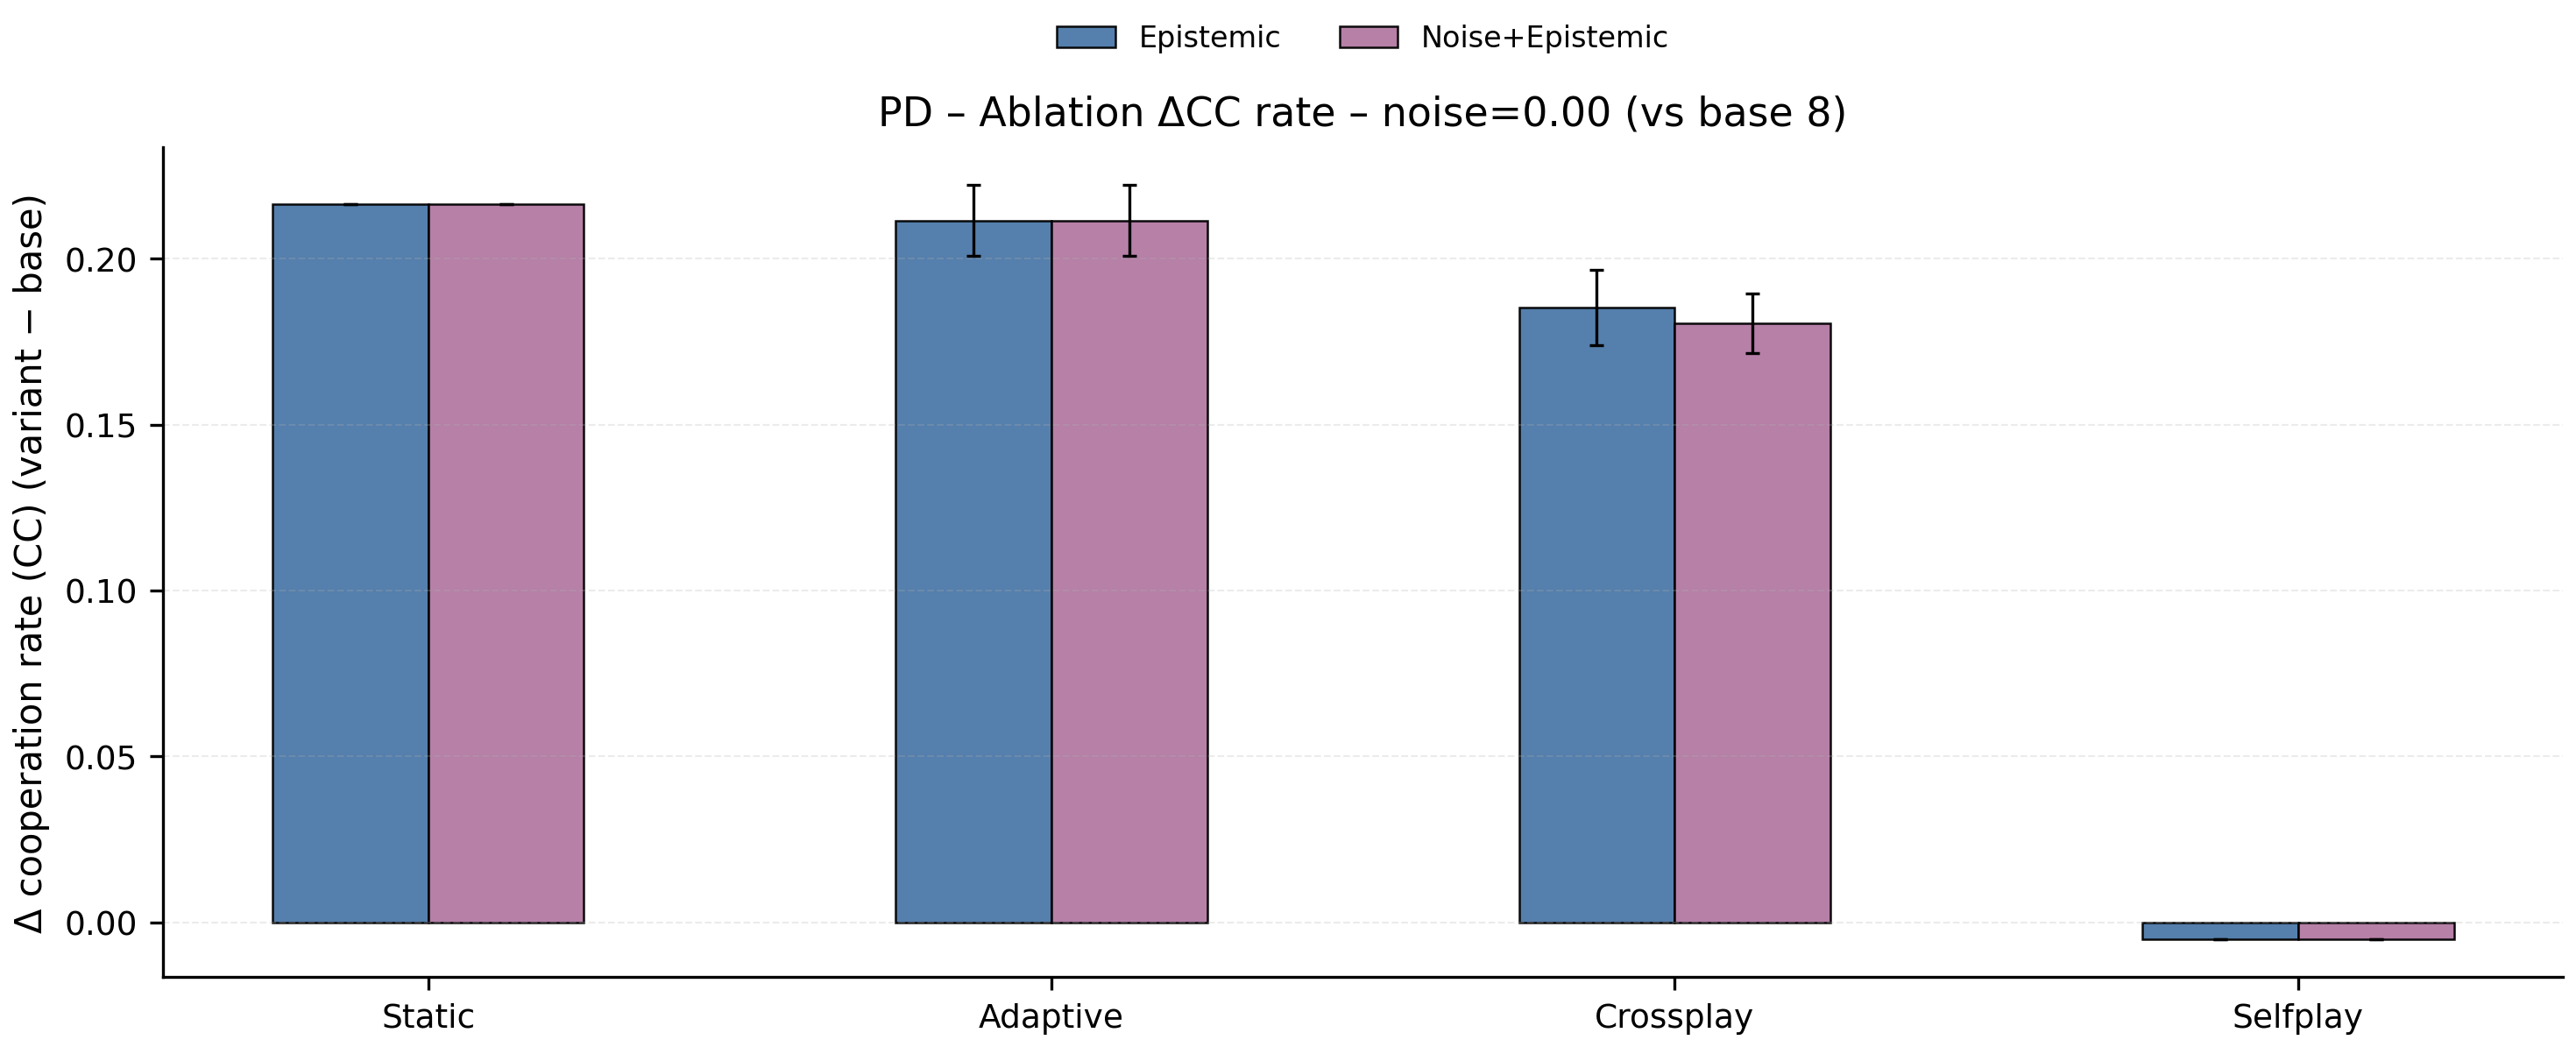

In [31]:
# Plot 7: Ablation deltas vs base (8) — ΔCC rate @ noise 0.00
plot_ablation_deltas(noise=NOISE_LEVELS[0], metric="cc_rate")

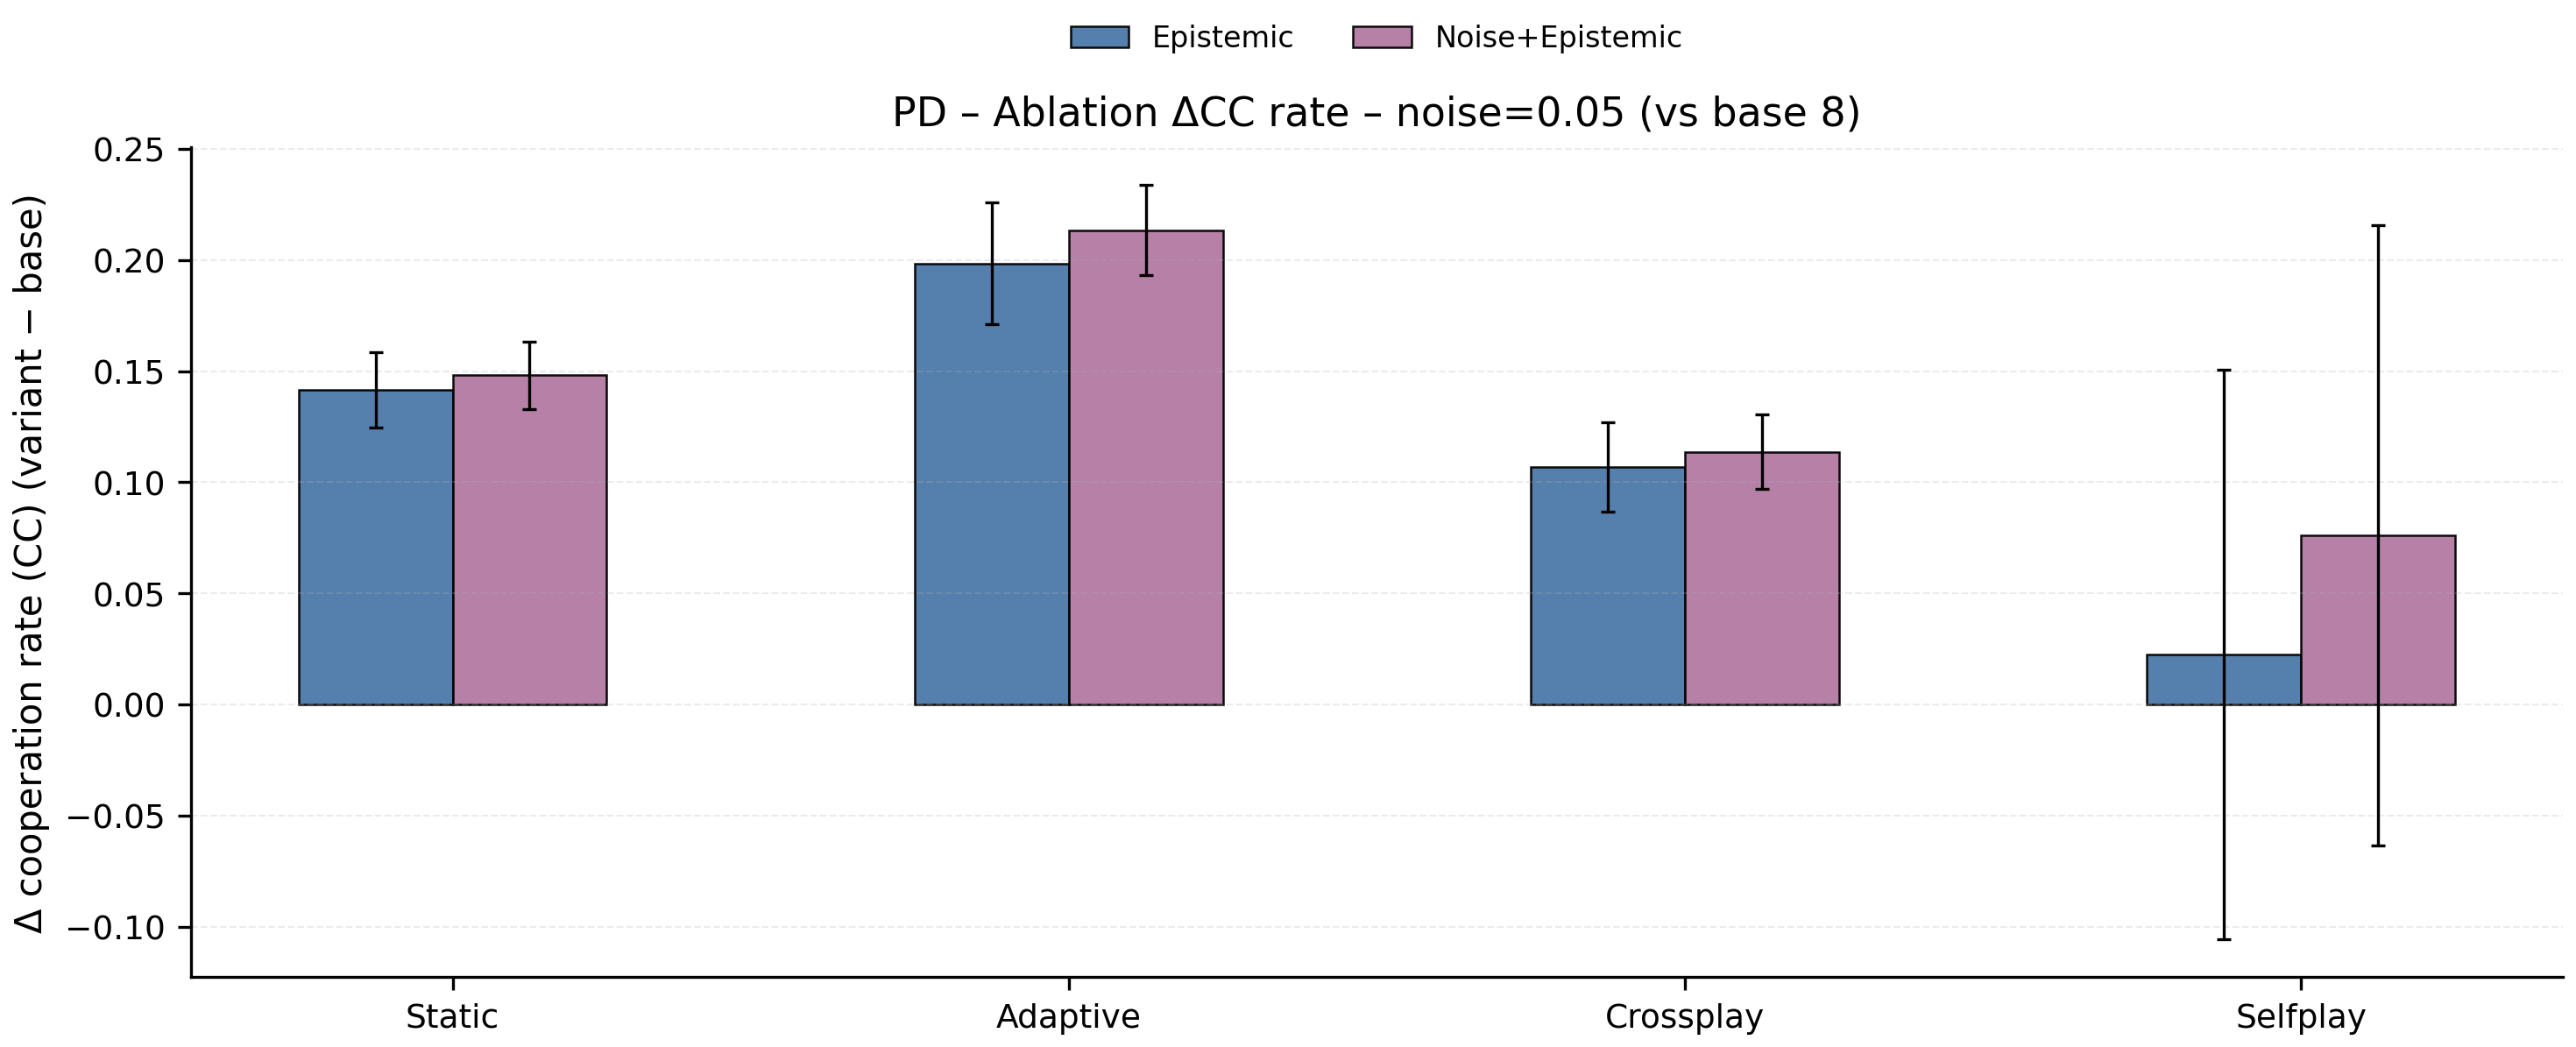

In [32]:
# Plot 8: Ablation deltas vs base (8) — ΔCC rate @ noise 0.05
plot_ablation_deltas(noise=NOISE_LEVELS[1], metric="cc_rate")